In [3]:
import requests
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os


BASE_URL = "http://localhost:8000"

def upload_eeg_file(file_path):
    file_path = os.path.expanduser(file_path)
    
    with open(file_path, 'rb') as f:
        files = {'file': (os.path.basename(file_path), f, 'application/octet-stream')}
        response = requests.post(f"{BASE_URL}/records/upload", files=files)
    return response.json()


def get_eeg_data(record_id):
    response = requests.get(f"{BASE_URL}/records/{record_id}/data")
    return np.array(response.json()['data'])

def get_predictions(record_id):
    response = requests.post(f"{BASE_URL}/records/{record_id}/predict")
    return response.json()

def plot_eeg_data(data, sample_rate=1000, channels=None):
    if channels is None:
        channels_to_plot = list(range(data.shape[0]))
    else:
        channels_to_plot = channels

    time = np.arange(data.shape[1]) / sample_rate

    plt.figure(figsize=(15, 8))
    for i in channels_to_plot:
        plt.plot(time, data[i], label=f'Channel {i+1}')

    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title('EEG Signals')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_predictions(predictions):
    state_colors = {
        'rest': 'green',
        'load': 'red',
        'recovery': 'blue'
    }
    
    plt.figure(figsize=(15, 4))
    
    legend_elements = [
        plt.Rectangle((0, 0), 1, 1, facecolor=color, alpha=0.3, label=state)
        for state, color in state_colors.items()
    ]
    
    for pred in predictions:
        plt.axvspan(
            pred['start_time'],
            pred['end_time'],
            alpha=0.3,
            color=state_colors[pred['state']]
        )
    
    plt.xlabel('Time (s)')
    plt.ylabel('State')
    plt.title('Predicted States')
    plt.legend(handles=legend_elements, loc='upper right')
    plt.grid(True)
    plt.show()

### Тестирование модели

На 8 экспериментуемом модель не обучалась.
- 2025-03-09_17.45.edf - 3 минуты в покое, 4 минуты нагрузки и 3 минуты начального периода восстановления
- 2025-03-09_17.54.edf - последние 4 минуты периода восстановления

In [16]:
# result = upload_eeg_file("~/EEGsignalsMarking/Data/08/2025-03-09_17.45.edf")
# result = upload_eeg_file("~/EEGsignalsMarking/Data/08/2025-03-09_17.54.edf")

In [4]:
resp = requests.get(BASE_URL + "/records/")
resp.raise_for_status()
df = pd.DataFrame(resp.json())
df

,filename,id,created_at,updated_at
0,2025-03-17_10.34.edf,1,2025-05-20T10:40:56.230065,2025-05-20T10:40:56.230072
1,2025-03-17_10.39.edf,2,2025-05-20T10:41:43.234970,2025-05-20T10:41:43.234975
2,2025-03-09_17.45.edf,3,2025-05-20T10:43:26.879030,2025-05-20T10:43:26.879038
3,2025-03-09_17.54.edf,4,2025-05-27T10:21:23.346219,2025-05-27T10:21:23.346225


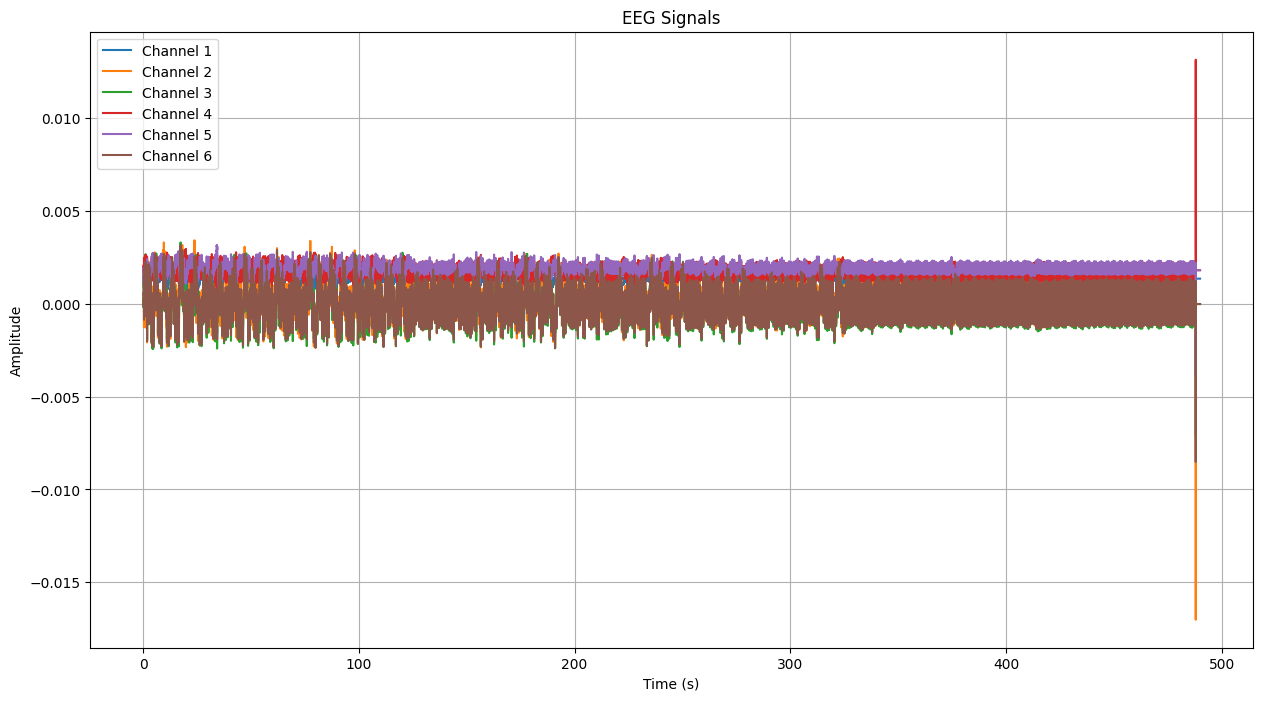

In [5]:
data = get_eeg_data(4)
plot_eeg_data(data)

In [6]:
predictions = get_predictions(2)

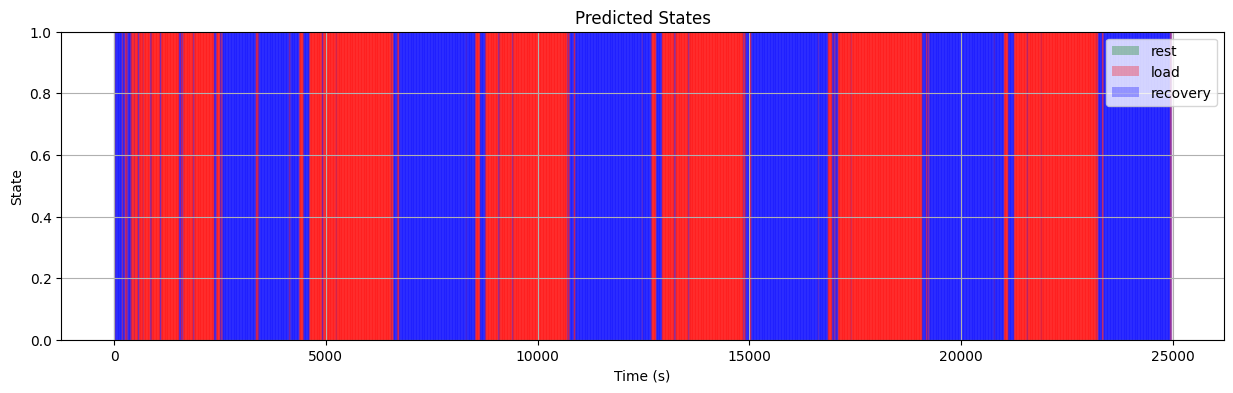

In [7]:
plot_predictions(predictions['predictions'])

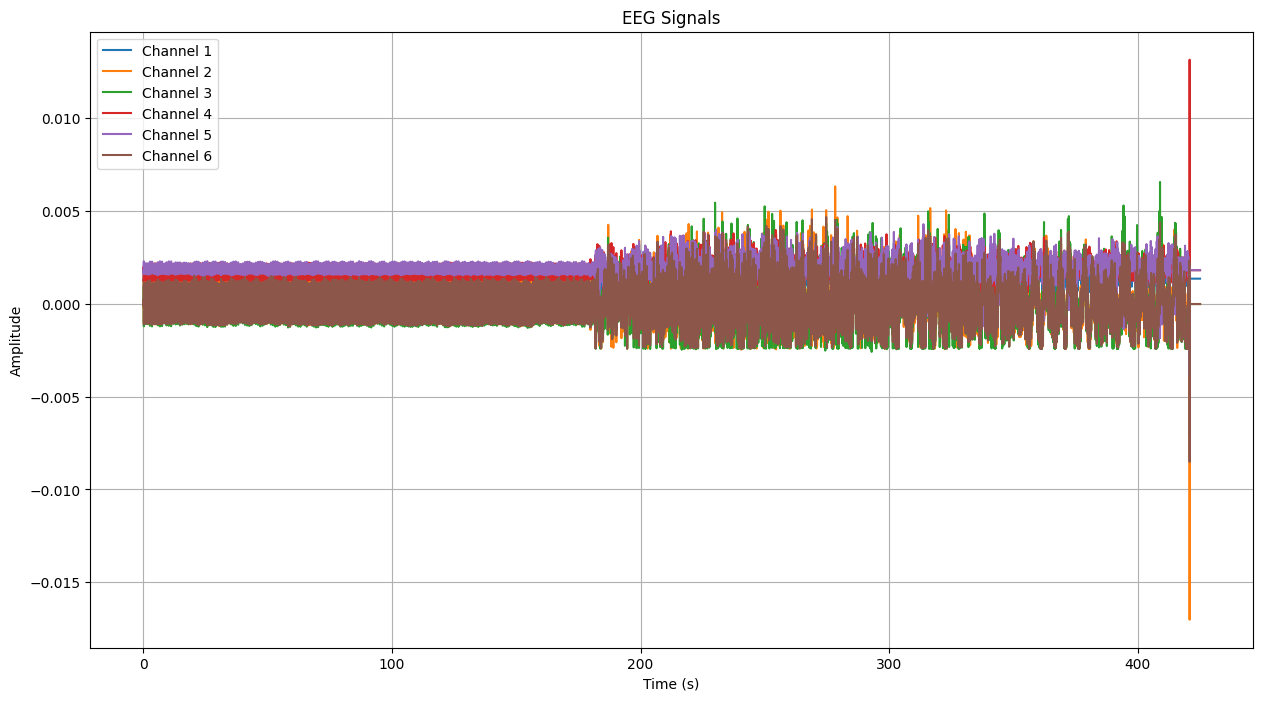

In [8]:
data = get_eeg_data(3)
plot_eeg_data(data)

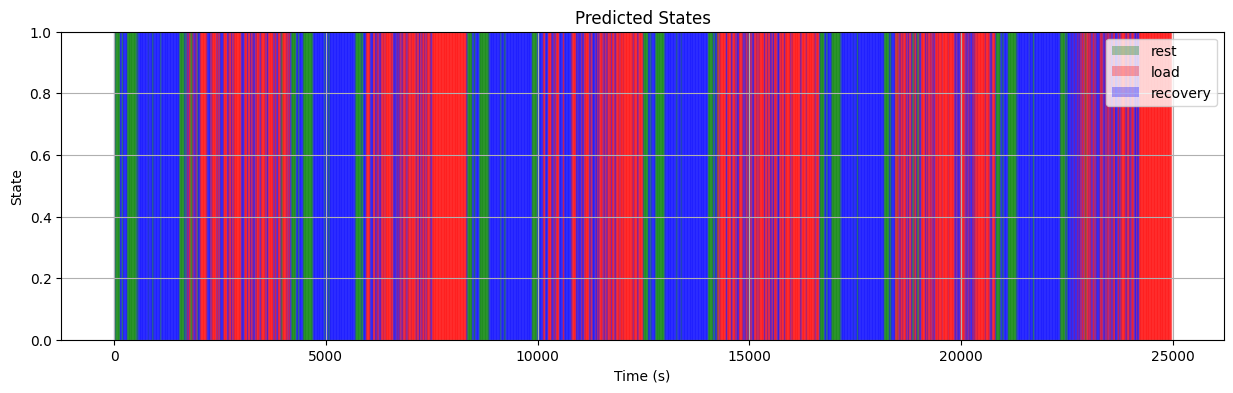

In [9]:
predictions = get_predictions(3)
plot_predictions(predictions['predictions'])